<a href="https://colab.research.google.com/github/Atharv-Chopade/Deep-Learning/blob/main/Dl_Day7_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
from tensorflow.keras.datasets import mnist
(X_train,y_train) , (X_test ,y_test) = mnist.load_data()

In [30]:
X_train  = (X_train / 255).reshape(-1,28,28,1)
X_test = (X_test / 255).reshape(-1,28,28,1)

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , Dense ,Dropout , Flatten
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import BatchNormalization , Dropout

In [32]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3),activation='relu' , input_shape = (28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128 , activation = 'relu'))
model.add(Dropout(0.2))
model.add(Dense(10 , activation = 'softmax'))

In [33]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile(optimizer='adam' , loss= 'sparse_categorical_crossentropy' , metrics = ['accuracy'])
history = model.fit(X_train , y_train , epochs = 5 , validation_split = 0.2 , validation_data = (X_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9468 - loss: 0.1776 - val_accuracy: 0.9830 - val_loss: 0.0513
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9811 - loss: 0.0605 - val_accuracy: 0.9853 - val_loss: 0.0426
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 22ms/step - accuracy: 0.9872 - loss: 0.0414 - val_accuracy: 0.9878 - val_loss: 0.0377
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9894 - loss: 0.0311 - val_accuracy: 0.9866 - val_loss: 0.0419
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9922 - loss: 0.0235 - val_accuracy: 0.9875 - val_loss: 0.0367


In [37]:
model.save("dropout.keras")

In [38]:
from tensorflow.keras.models import load_model
model = load_model('dropout.keras')

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_696/763147451.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


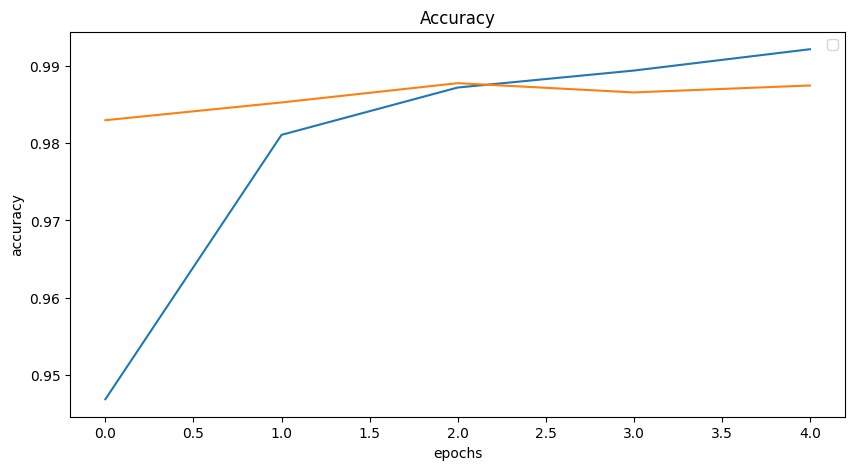

In [41]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'] )
plt.plot(history.history['val_accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Accuracy')
plt.legend()
plt.show()

/tmp/ipykernel_696/2080025284.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


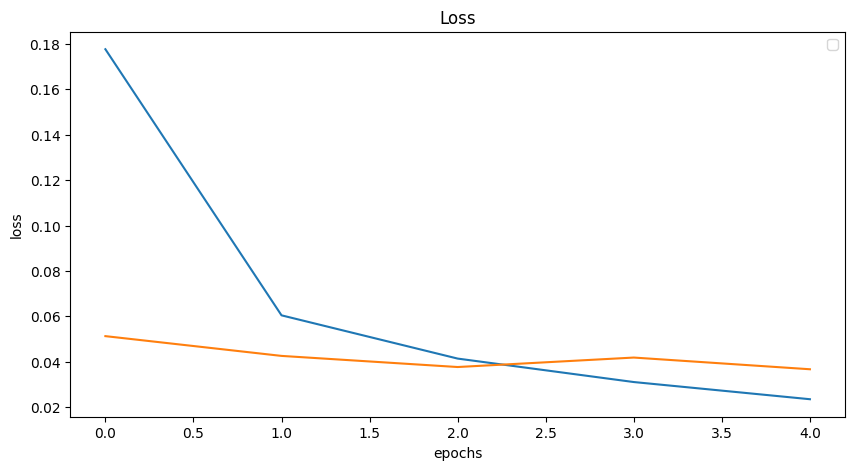

In [42]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'] )
plt.xlabel('epochs')
plt.ylabel('loss')
plt.title('Loss')
plt.legend()
plt.show()

In [43]:
import numpy as np

prediction = model.predict(X_test[0].reshape(1,28,28,1))
print(prediction)
print(y_test[0])
print(np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
[[2.4525870e-09 4.3136379e-07 5.4302117e-08 3.5285761e-06 3.3647807e-09
  1.0464076e-10 8.9018589e-15 9.9999225e-01 1.6150377e-08 3.5074229e-06]]
7
7


Compare Model with ans Without Dropout

With


In [47]:
import time
st = time.time()
model_drop = Sequential()
model_drop.add(Conv2D(32,kernel_size=(3,3),activation='relu' , input_shape = (28,28,1)))
model_drop.add(MaxPooling2D(pool_size=(2,2)))
model_drop.add(Flatten())
model_drop.add(Dense(128 , activation = 'relu'))
model_drop.add(Dropout(0.2))
model_drop.add(Dense(10 , activation = 'softmax'))

model_drop.compile(optimizer = 'adam' , loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'])
history_drop = model_drop.fit(X_train,y_train,epochs = 5 , batch_size = 500 , validation_split = 0.2,validation_data=(X_test , y_test))
end = time.time()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 33s 267ms/step - accuracy: 0.8791 - loss: 0.4214 - val_accuracy: 0.9537 - val_loss: 0.1555
Epoch 2/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - accuracy: 0.9599 - loss: 0.1378 - val_accuracy: 0.9753 - val_loss: 0.0846
Epoch 3/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 38s 238ms/step - accuracy: 0.9742 - loss: 0.0890 - val_accuracy: 0.9807 - val_loss: 0.0639
Epoch 4/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 235ms/step - accuracy: 0.9806 - loss: 0.0669 - val_accuracy: 0.9805 - val_loss: 0.0579
Epoch 5/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 235ms/step - accuracy: 0.9843 - loss: 0.0542 - val_accuracy: 0.9849 - val_loss: 0.0456


Without

In [48]:
st1 = time.time()
model_no_dropout = Sequential()
model_no_dropout.add(Conv2D(32,kernel_size=(3,3),activation='relu' , input_shape = (28,28,1)))
model_no_dropout.add(MaxPooling2D(pool_size=(2,2)))
model_no_dropout.add(Flatten())
model_no_dropout.add(Dense(128 , activation = 'relu'))
model_no_dropout.add(Dense(10 , activation = 'softmax'))

model_no_dropout.compile(optimizer = 'adam' , loss = 'sparse_categorical_crossentropy' , metrics = ['accuracy'])
history_no_dropout = model_no_dropout.fit(X_train,y_train,epochs = 5 , batch_size = 500 , validation_split = 0.2,validation_data=(X_test , y_test))
end1 = time.time()

Epoch 1/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 30s 238ms/step - accuracy: 0.8885 - loss: 0.4013 - val_accuracy: 0.9467 - val_loss: 0.1800
Epoch 2/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 40s 233ms/step - accuracy: 0.9583 - loss: 0.1432 - val_accuracy: 0.9702 - val_loss: 0.1070
Epoch 3/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 42s 238ms/step - accuracy: 0.9758 - loss: 0.0862 - val_accuracy: 0.9769 - val_loss: 0.0749
Epoch 4/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 42s 243ms/step - accuracy: 0.9819 - loss: 0.0617 - val_accuracy: 0.9808 - val_loss: 0.0547
Epoch 5/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 28s 233ms/step - accuracy: 0.9866 - loss: 0.0472 - val_accuracy: 0.9833 - val_loss: 0.0486


In [51]:
dropouttime = end- st
nodropouttime = end1 - st1

In [52]:
dropouttime

181.66155433654785

In [53]:
nodropouttime

181.4644501209259